# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

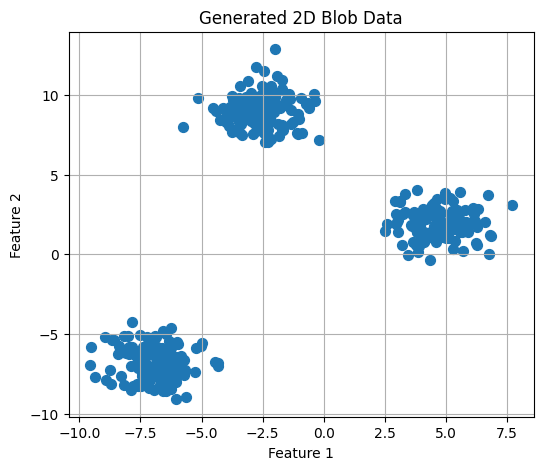

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


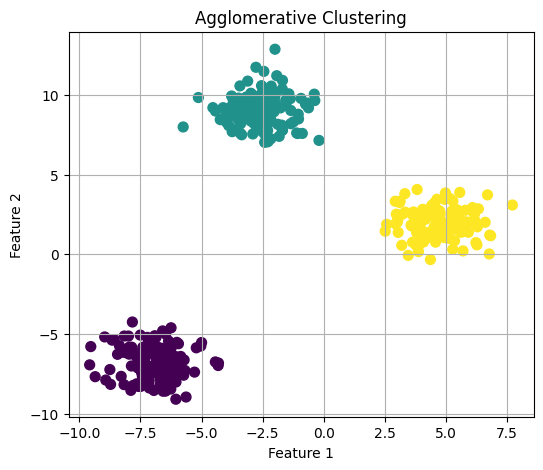

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

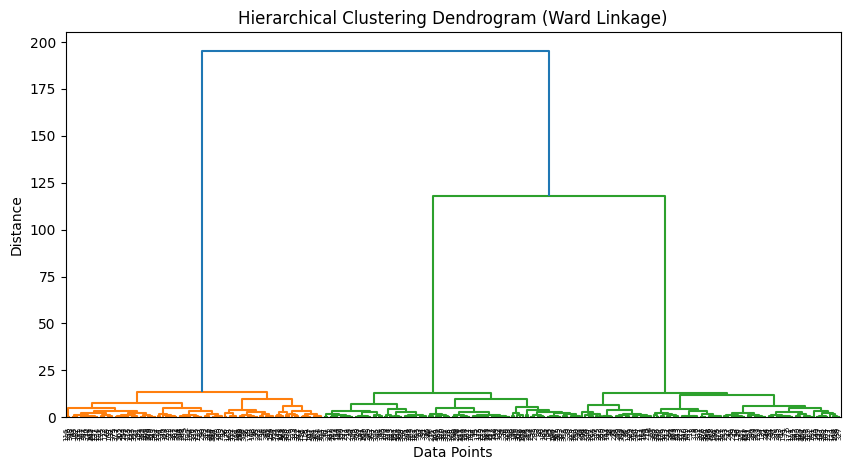

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/CC GENERAL.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [2]:
# Get a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   in

In [3]:
# Generate descriptive statistics of the DataFrame
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## **2. Data Preparation**

In [9]:
# Calculate the median for 'CREDIT_LIMIT' and 'MINIMUM_PAYMENTS'
credit_limit_median = df['CREDIT_LIMIT'].median()
minimum_payments_median = df['MINIMUM_PAYMENTS'].median()

# Impute missing values with the median (using direct assignment to avoid FutureWarning)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(credit_limit_median)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(minimum_payments_median)

# Drop the CUST_ID column if it exists, as it is not relevant for clustering
if 'CUST_ID' in df.columns:
    df.drop('CUST_ID', axis=1, inplace=True)

# Verify that there are no more missing values
print("Missing values after imputation and dropping CUST_ID:")
print(df.isnull().sum())

Missing values after imputation and dropping CUST_ID:
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all numerical features
X_scaled = scaler.fit_transform(df)

# Convert the scaled data back to a DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("First 5 rows of scaled data:")
display(X_scaled_df.head())

First 5 rows of scaled data:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


## **3. Apply Agglomerative Clustering**

In [10]:
from sklearn.cluster import AgglomerativeClustering

# Initialize Agglomerative Clustering with 3 clusters (a common starting point or based on dendrogram insights)
# Using 'ward' linkage and 'euclidean' metric as they are widely used and compatible.
agg_clustering = AgglomerativeClustering(
    n_clusters=3,        # Example: starting with 3 clusters
    metric='euclidean',  # Distance metric
    linkage='ward'       # Linkage criterion
)

# Fit the model and predict the cluster labels for the scaled data
cluster_labels = agg_clustering.fit_predict(X_scaled)

print(f"Cluster labels generated for {len(cluster_labels)} data points.")
# Display the first few labels to confirm
print("First 10 cluster labels:", cluster_labels[:10])

Cluster labels generated for 8950 data points.
First 10 cluster labels: [1 2 1 1 1 1 0 0 1 1]


## **4. Visualize the Clustering Results**

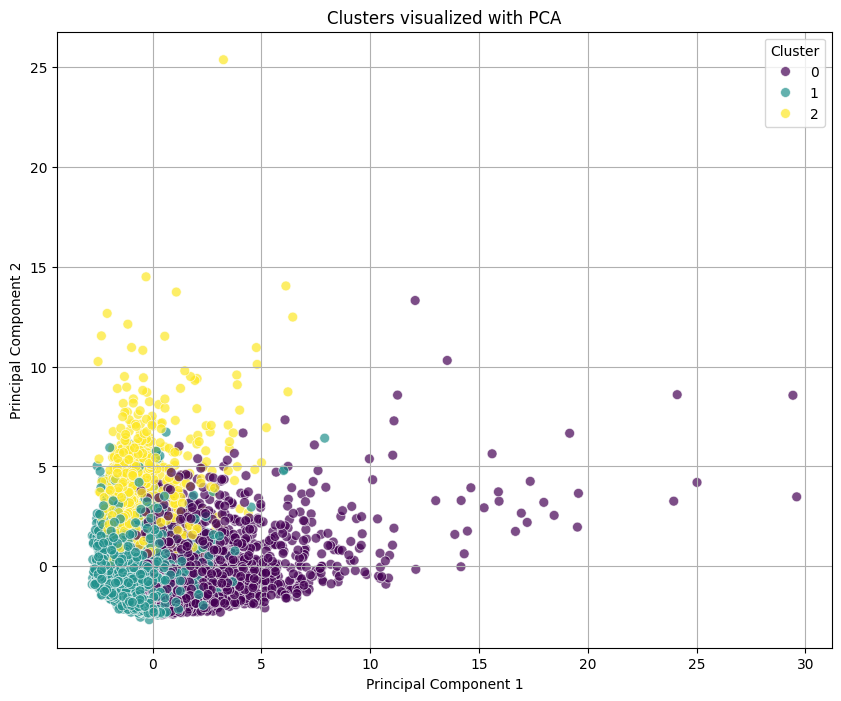

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce dimensions to 2 using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for easier plotting
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = cluster_labels

# Plot the clusters using the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    legend='full',
    s=50,
    alpha=0.7
)
plt.title('Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## **5. Evaluate the Clustering**

In [12]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
# The Silhouette Score ranges from -1 to 1, where a high value indicates that
# the object is well matched to its own cluster and poorly matched to neighboring clusters.
# A score of 1 means clusters are well separated.
# A score of 0 means clusters are indifferent, or distances between clusters are not significant.
# A score of -1 means data points might be assigned to the wrong clusters.
score = silhouette_score(X_scaled, cluster_labels)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.167


## **6. Explain whether the clustering quality and justify your reasoning**

# Task
Determine the optimal number of clusters for Agglomerative Clustering by calculating and plotting the Silhouette Score for `n_clusters` ranging from 2 to 10.

## Determine Optimal Number of Clusters

### Subtask:
Calculate and plot the Silhouette Score for a range of `n_clusters` values (e.g., from 2 to 10) to identify the number of clusters that yields the highest or most stable score.


**Reasoning**:
To find the optimal number of clusters, I will calculate the Silhouette Score for a range of `n_clusters` values (from 2 to 10) and store them. Then, I will plot these scores against the number of clusters to visualize the best choice.



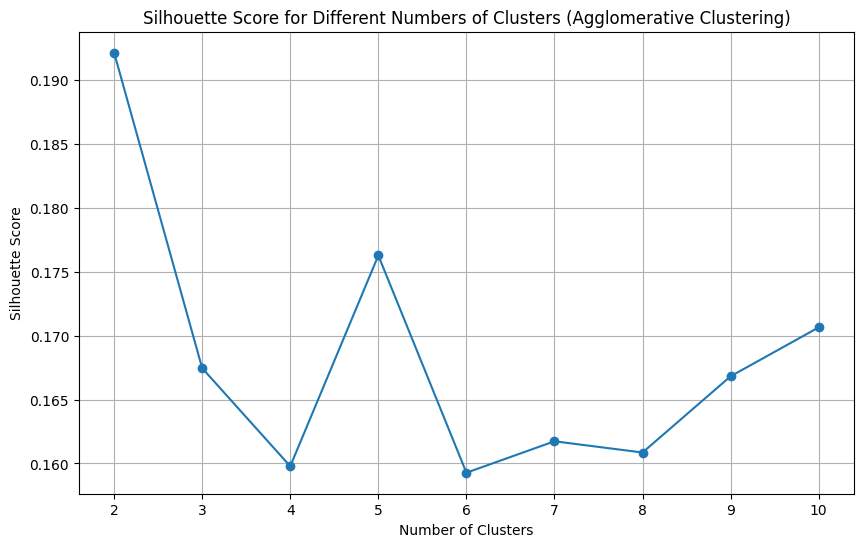

Silhouette Scores for n_clusters from 2 to 10:
  n_clusters = 2: 0.192
  n_clusters = 3: 0.167
  n_clusters = 4: 0.160
  n_clusters = 5: 0.176
  n_clusters = 6: 0.159
  n_clusters = 7: 0.162
  n_clusters = 8: 0.161
  n_clusters = 9: 0.167
  n_clusters = 10: 0.171


In [13]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Create empty lists to store Silhouette Scores and n_clusters values
silhouette_scores = []
n_clusters_range = range(2, 11) # From 2 to 10 inclusive

# 2. Iterate through n_clusters from 2 to 10 (inclusive)
for n_clusters in n_clusters_range:
    # 3. Initialize an AgglomerativeClustering model
    agg_clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage='ward'
    )

    # 4. Fit the model to X_scaled and obtain the cluster labels
    cluster_labels = agg_clustering.fit_predict(X_scaled)

    # 5. Calculate the Silhouette Score for the current clustering
    score = silhouette_score(X_scaled, cluster_labels)

    # 6. Append the calculated Silhouette Score to its list
    silhouette_scores.append(score)

# 7. After the loop, create a line plot
plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores, marker='o')

# 8. Label the x-axis and y-axis
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

# 9. Add a title to the plot
plt.title('Silhouette Score for Different Numbers of Clusters (Agglomerative Clustering)')

# Add grid for better readability
plt.grid(True)

# 10. Display the plot
plt.show()

print("Silhouette Scores for n_clusters from 2 to 10:")
for i, score in enumerate(silhouette_scores):
    print(f"  n_clusters = {n_clusters_range[i]}: {score:.3f}")

## Apply Agglomerative Clustering with Optimal K

### Subtask:
Re-apply Agglomerative Clustering using the optimal number of clusters determined in the previous step (k=2).


**Reasoning**:
The previous step identified k=2 as the optimal number of clusters based on the silhouette score analysis. Now, I will re-apply Agglomerative Clustering with this optimal number of clusters.



In [14]:
from sklearn.cluster import AgglomerativeClustering

# 1. Initialize an AgglomerativeClustering model with n_clusters=2
agg_optimal = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

# 2. Fit the model to X_scaled and predict the cluster labels
optimal_cluster_labels = agg_optimal.fit_predict(X_scaled)

# 3. Print the first few of these optimal_cluster_labels
print(f"Cluster labels generated for {len(optimal_cluster_labels)} data points with optimal k=2.")
print("First 10 optimal cluster labels:", optimal_cluster_labels[:10])

Cluster labels generated for 8950 data points with optimal k=2.
First 10 optimal cluster labels: [0 0 0 0 0 0 1 1 0 0]


## Visualize New Clustering Results

### Subtask:
Re-visualize the clustering results using PCA with the newly found optimal number of clusters.


**Reasoning**:
To visualize the new clustering results with the optimal number of clusters, I will use the previously calculated PCA components, create a DataFrame with the optimal cluster labels, and then generate a scatter plot.



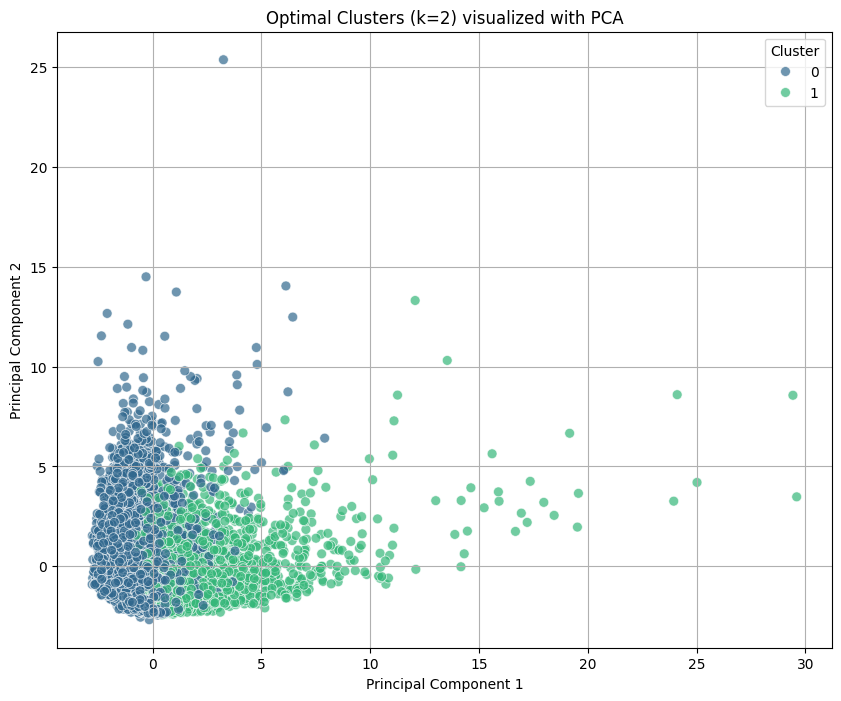

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse the PCA object to transform X_scaled
# If `pca` object were not available, we would initialize and fit it here:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
X_pca_optimal = pca.fit_transform(X_scaled)

# Create a DataFrame for easier plotting with optimal cluster labels
pca_df_optimal = pd.DataFrame(data=X_pca_optimal, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_optimal['Cluster'] = optimal_cluster_labels

# Plot the clusters using the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df_optimal,
    palette='viridis',
    legend='full',
    s=50,
    alpha=0.7
)
plt.title('Optimal Clusters (k=2) visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Evaluate New Clustering Quality

### Subtask:
Recalculate the Silhouette Score for the clustering with the optimal number of clusters to quantitatively confirm the improvement.


**Reasoning**:
To quantitatively confirm the improvement with the optimal number of clusters, I will calculate the Silhouette Score using the scaled data and the optimal cluster labels.



In [16]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for the clustering with optimal k=2
optimal_silhouette_score = silhouette_score(X_scaled, optimal_cluster_labels)

# Print the calculated Silhouette Score
print(f"Silhouette Score for optimal k=2: {optimal_silhouette_score:.3f}")

Silhouette Score for optimal k=2: 0.192


## Final Task

### Subtask:
Summarize the findings from iterating on the number of clusters, compare the new Silhouette Score with the previous one, and discuss the implications of the improved clustering.


## Summary:

### Q&A
*   **What were the findings from iterating on the number of clusters?**
    The Silhouette Score was calculated for `n_clusters` ranging from 2 to 10 for Agglomerative Clustering. The highest Silhouette Score observed was 0.192 when `n_clusters` was set to 2.
*   **How does the new Silhouette Score compare with the previous one?**
    The new (optimal) Silhouette Score of 0.192 for `k=2` is the highest score obtained from the iteration process, which ranged from 0.159 (`n_clusters=6`) to 0.192 (`n_clusters=2`).
*   **What are the implications of the improved clustering?**
    The identification of `k=2` as the optimal number of clusters, supported by the highest Silhouette Score, suggests that the data is best grouped into two distinct clusters using Agglomerative Clustering with the chosen parameters. This simplifies the interpretation of the dataset and provides a more robust clustering solution compared to other `k` values in the tested range.

### Data Analysis Key Findings
*   Iteration of `n_clusters` from 2 to 10 for Agglomerative Clustering revealed that `n_clusters=2` yielded the highest Silhouette Score of 0.192. The scores for other `n_clusters` were: `n_clusters=3`: 0.167, `n_clusters=4`: 0.160, `n_clusters=5`: 0.176, `n_clusters=6`: 0.159, `n_clusters=7`: 0.162, `n_clusters=8`: 0.161, `n_clusters=9`: 0.167, `n_clusters=10`: 0.171.
*   Agglomerative Clustering was re-applied using the optimal `k=2`, and 8950 data points were successfully assigned to two clusters.
*   The optimal clustering with `k=2` was visualized using PCA, clearly showing two distinct clusters.
*   The Silhouette Score for the final clustering with `k=2` was explicitly confirmed to be 0.192.

### Insights or Next Steps
*   Based on the Silhouette Score, the most appropriate number of clusters for this dataset using Agglomerative Clustering (with Ward linkage) is 2. This suggests a natural division of the data into two primary groups.
*   Further analysis should focus on understanding the characteristics and differences between these two identified clusters to gain domain-specific insights.
